# Assignment -visualization of dataset and data cleaning
## Step 1 - The metadata (the description of the dataset) is exlored

In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
# ============================================================
# CELL 2 — Load Metadata
# ============================================================
df = pd.read_csv('data/metadata.csv')

print("Shape:", df.shape) #10 cols and 7565 samples
print("\nColumn Names:\n", df.columns.tolist()) #feature-list giving the 10 feature names

Shape: (7565, 10)

Column Names:
 ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


In [3]:
# ============================================================
# CELL 3 — First & Last Look
# ============================================================
print("=== FIRST 5 ROWS ===")
display(df.head()) #first five data

print("\n=== LAST 5 ROWS ===")
display(df.tail()) #last 5 data

=== FIRST 5 ROWS ===


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN



=== LAST 5 ROWS ===


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN
7564,charge,[2010. 9. 30. 12. 31. ...,4,B0055,251,7565,07565.csv,NaN,NaN,NaN


In [4]:
# ============================================================
# CELL 4 — Data Types & Memory
# ============================================================
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MEMORY USAGE ===")
print(df.memory_usage(deep=True))  #gives all the memory used by each of the data type. simply explains how much memory is used in keeping any kind of data
# one problem to be noted that the capacity, re, rct are all strings where they should have been int or floats so need to convert them later.

=== DATA TYPES ===
type                     str
start_time               str
ambient_temperature    int64
battery_id               str
test_id                int64
uid                    int64
filename                 str
Capacity                 str
Re                       str
Rct                      str
dtype: object

=== MEMORY USAGE ===
Index                     132
type                   430325
start_time             794182
ambient_temperature     60520
battery_id             408510
test_id                 60520
uid                     60520
filename               438770
Capacity               338732
Re                     312617
Rct                    312261
dtype: int64


In [5]:
# Fix Capacity, Re, Rct — convert from str to float
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')
df['Re']       = pd.to_numeric(df['Re'],       errors='coerce')
df['Rct']      = pd.to_numeric(df['Rct'],      errors='coerce')

# Verify
print(df[['Capacity', 'Re', 'Rct']].dtypes)

Capacity    float64
Re          float64
Rct         float64
dtype: object


In [6]:
# ============================================================
# CELL 5 — Missing Values
# ============================================================
print("=== MISSING VALUES PER COLUMN ===")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)

=== MISSING VALUES PER COLUMN ===
                     Missing Count  Missing %
type                             0       0.00
start_time                       0       0.00
ambient_temperature              0       0.00
battery_id                       0       0.00
test_id                          0       0.00
uid                              0       0.00
filename                         0       0.00
Capacity                      4796      63.40
Re                            5618      74.26
Rct                           5618      74.26


In [7]:
print(df['type'].value_counts())

type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL — Find truly missing values
# ============================================================

# Discharge rows missing Capacity
missing_capacity = df[(df['type'] == 'discharge') & (df['Capacity'].isnull())]
print(f"Discharge rows missing Capacity: {len(missing_capacity)}")
display(missing_capacity)

# Impedance rows missing Re or Rct
missing_impedance = df[(df['type'] == 'impedance') & (df['Re'].isnull())]
print(f"\nImpedance rows missing Re/Rct: {len(missing_impedance)}")
display(missing_impedance)

Discharge rows missing Capacity: 25


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
4370,discharge,[2010. 8. 29. 7. 9. ...,4,B0050,52,4371,04371.csv,NaN,NaN,NaN
4372,discharge,[2010. 8. 29. 10. 39. ...,4,B0050,54,4373,04373.csv,NaN,NaN,NaN
4374,discharge,[2010. 8. 29. 14. 11. ...,4,B0050,56,4375,04375.csv,NaN,NaN,NaN
4376,discharge,[2010. 8. 29. 17. 40. ...,4,B0050,58,4377,04377.csv,NaN,NaN,NaN
4390,discharge,[2010. 8. 26. 11. 4. ...,4,B0052,10,4391,04391.csv,NaN,NaN,NaN
4394,discharge,[2010. 8. 26. 16. 34. ...,4,B0052,14,4395,04395.csv,NaN,NaN,NaN
4396,discharge,[2010. 8. 26. 21. 7. ...,4,B0052,16,4397,04397.csv,NaN,NaN,NaN
4398,discharge,[2010. 8. 27. 0. 53. ...,4,B0052,18,4399,04399.csv,NaN,NaN,NaN
4400,discharge,[2010. 8. 27. 4. 41. ...,4,B0052,20,4401,04401.csv,NaN,NaN,NaN
4402,discharge,[2010. 8. 27. 8. 27. ...,4,B0052,22,4403,04403.csv,NaN,NaN,NaN



Impedance rows missing Re/Rct: 9


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
4267,impedance,[2010. 8. 26. 12. 25. ...,24,B0049,11,4268,04268.csv,NaN,NaN,NaN
4279,impedance,[2010. 8. 27. 9. 22. ...,24,B0049,23,4280,04280.csv,NaN,NaN,NaN
4281,impedance,[2010. 8. 27. 12. 59. ...,24,B0049,25,4282,04282.csv,NaN,NaN,NaN
4291,impedance,[2.01e+03 8.00e+00 2.80e+01 4.00e+00 5.30e+01 ...,24,B0049,35,4292,04292.csv,NaN,NaN,NaN
4293,impedance,[2010. 8. 28. 8. 29. ...,24,B0049,37,4294,04294.csv,NaN,NaN,NaN
4305,impedance,[2010. 8. 29. 3. 5. ...,24,B0049,49,4306,04306.csv,NaN,NaN,NaN
4315,impedance,[2010. 8. 29. 18. 14. ...,24,B0049,59,4316,04316.csv,NaN,NaN,NaN
4317,impedance,[2010. 8. 29. 21. 51. ...,24,B0049,61,4318,04318.csv,NaN,NaN,NaN
4453,impedance,[2010. 8. 26. 12. 25. ...,24,B0051,11,4454,04454.csv,NaN,NaN,NaN


In [9]:
# ============================================================
# CELL — Drop truly missing rows
# ============================================================

before = len(df)

# Drop discharge rows with missing Capacity
df = df.drop(missing_capacity.index)

# Drop impedance rows with missing Re/Rct
df = df.drop(missing_impedance.index)

after = len(df)

print(f"Rows before: {before}")
print(f"Rows dropped: {before - after}")
print(f"Rows after:  {after}")

Rows before: 7565
Rows dropped: 34
Rows after:  7531


In [10]:
# ============================================================
# CELL — Duplicates Check
# ============================================================
print(f"Duplicate rows:      {df.duplicated().sum()}")
print(f"Duplicate UIDs:      {df['uid'].duplicated().sum()}")
print(f"Duplicate filenames: {df['filename'].duplicated().sum()}")

Duplicate rows:      0
Duplicate UIDs:      0
Duplicate filenames: 0


In [11]:
# ============================================================
# CELL — Load all CSVs into 3 separate dataframes
# ============================================================
import os
import pandas as pd

DATA_PATH = 'data/data/'

charge_dfs    = []
discharge_dfs = []
impedance_dfs = []

for _, row in df.iterrows():
    filepath = os.path.join(DATA_PATH, row['filename'])

    if not os.path.exists(filepath):
        continue

    temp = pd.read_csv(filepath)

    # Add identifying columns from metadata
    temp['battery_id']          = row['battery_id']
    temp['cycle_type']          = row['type']
    temp['ambient_temperature'] = row['ambient_temperature']
    temp['test_id']             = row['test_id']
    temp['uid']                 = row['uid']

    if row['type'] == 'charge':
        charge_dfs.append(temp)
    elif row['type'] == 'discharge':
        discharge_dfs.append(temp)
    elif row['type'] == 'impedance':
        impedance_dfs.append(temp)

# Combine
charge_df    = pd.concat(charge_dfs,    ignore_index=True)
discharge_df = pd.concat(discharge_dfs, ignore_index=True)
impedance_df = pd.concat(impedance_dfs, ignore_index=True)

print("Charge shape:   ", charge_df.shape)
print("Discharge shape:", discharge_df.shape)
print("Impedance shape:", impedance_df.shape)

Charge shape:    (6512876, 11)
Discharge shape: (764674, 11)
Impedance shape: (93456, 10)


In [12]:
# ============================================================
# CELL — Quick look at all 3 dataframes
# ============================================================

print("=== CHARGE ===")
display(charge_df.head(3))
print("\nColumns:", charge_df.columns.tolist())

print("\n=== DISCHARGE ===")
display(discharge_df.head(3))
print("\nColumns:", discharge_df.columns.tolist())

print("\n=== IMPEDANCE ===")
display(impedance_df.head(3))
print("\nColumns:", impedance_df.columns.tolist())

=== CHARGE ===


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,battery_id,cycle_type,ambient_temperature,test_id,uid
0,3.486189,0.001417,5.990142,-0.0006,0.002,0.000,B0047,charge,4,2,3
1,3.746592,1.489057,5.992528,1.4995,4.618,2.594,B0047,charge,4,2,3
2,3.775438,1.490426,5.991340,1.4995,4.669,8.922,B0047,charge,4,2,3



Columns: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time', 'battery_id', 'cycle_type', 'ambient_temperature', 'test_id', 'uid']

=== DISCHARGE ===


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,battery_id,cycle_type,ambient_temperature,test_id,uid
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000,B0047,discharge,4,0,1
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360,B0047,discharge,4,0,1
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281,B0047,discharge,4,0,1



Columns: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'battery_id', 'cycle_type', 'ambient_temperature', 'test_id', 'uid']

=== IMPEDANCE ===


,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,battery_id,cycle_type,ambient_temperature,test_id,uid
0,(928.3472290039062-48.499576568603516j),(228.7861328125-70.94481658935547j),(3.76172584438583+0.9544956717274271j),(0.19021741554080737+0.07913959666077047j),(0.17493022756754967-0.02331644173631698j),B0047,impedance,24,1,2
1,(922.0059814453125-52.15481185913086j),(233.29783630371094-67.84492492675781j),(3.70383574337748+0.8535511912426126j),(0.012482111540534805+0.03664975726191017j),(0.16866854345060991-0.024717137242854174j),B0047,impedance,24,1,2
2,(920.0405883789062-52.19926452636719j),(236.62075805664062-67.22105407714844j),(3.6558702379340415+0.8179848126025503j),(0.030461237041852884-0.08529386061204824j),(0.16107808875912483-0.024114907529065532j),B0047,impedance,24,1,2



Columns: ['Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance', 'battery_id', 'cycle_type', 'ambient_temperature', 'test_id', 'uid']


In [13]:
# ============================================================
# CELL — Missing values in each
# ============================================================

for name, dataframe in [('charge', charge_df),
                         ('discharge', discharge_df),
                         ('impedance', impedance_df)]:
    print(f"\n=== {name.upper()} MISSING VALUES ===")
    missing = pd.DataFrame({
        'Missing Count': dataframe.isnull().sum(),
        'Missing %': (dataframe.isnull().sum() / len(dataframe) * 100).round(2)
    })
    print(missing)


=== CHARGE MISSING VALUES ===
                      Missing Count  Missing %
Voltage_measured                257        0.0
Current_measured                257        0.0
Temperature_measured            257        0.0
Current_charge                    0        0.0
Voltage_charge                    0        0.0
Time                              0        0.0
battery_id                        0        0.0
cycle_type                        0        0.0
ambient_temperature               0        0.0
test_id                           0        0.0
uid                               0        0.0

=== DISCHARGE MISSING VALUES ===
                      Missing Count  Missing %
Voltage_measured                  0        0.0
Current_measured                  0        0.0
Temperature_measured              0        0.0
Current_load                      0        0.0
Voltage_load                      0        0.0
Time                              0        0.0
battery_id                        0       

In [14]:
charge_df = charge_df.dropna(subset=['Voltage_measured', 'Current_measured', 'Temperature_measured'])
print("Charge after dropping:", charge_df.shape)

Charge after dropping: (6512619, 11)


In [15]:
# Convert all complex string columns to actual complex numbers
for col in ['Sense_current', 'Battery_current', 'Current_ratio',
            'Battery_impedance', 'Rectified_Impedance']:
    impedance_df[col] = impedance_df[col].apply(
        lambda x: complex(x) if pd.notna(x) else x
    )

In [16]:
# Compare real parts where both exist
both_exist = impedance_df.dropna(subset=['Rectified_Impedance'])

print("Battery_impedance real part mean:     ",
      both_exist['Battery_impedance'].apply(lambda x: x.real).mean())
print("Rectified_Impedance real part mean:   ",
      both_exist['Rectified_Impedance'].apply(lambda x: x.real).mean())

Battery_impedance real part mean:      10548235736.242933
Rectified_Impedance real part mean:    6671876667.791428


In [17]:
# ============================================================
# CELL — Sanity check the complex values
# ============================================================

# Look at a few raw values
print("=== RAW VALUES SAMPLE ===")
print(impedance_df[['Battery_impedance', 'Rectified_Impedance']].head(10).to_string())

# Check real part distribution
batt_real = impedance_df['Battery_impedance'].apply(lambda x: x.real if isinstance(x, complex) else None)
rect_real = impedance_df['Rectified_Impedance'].apply(lambda x: x.real if isinstance(x, complex) else None)

print("\n=== Battery_impedance real part stats ===")
print(batt_real.describe())

print("\n=== Rectified_Impedance real part stats ===")
print(rect_real.describe())

=== RAW VALUES SAMPLE ===
    Battery_impedance  Rectified_Impedance
0  0.190217+0.079140j   0.174930-0.023316j
1  0.012482+0.036650j   0.168669-0.024717j
2  0.030461-0.085294j   0.161078-0.024115j
3  0.142294-0.121922j   0.149244-0.023729j
4  0.243882-0.080332j   0.140498-0.022852j
5  0.303109-0.011000j   0.131157-0.022424j
6  0.327091+0.051457j   0.123046-0.019510j
7  0.330900+0.093557j   0.113448-0.017644j
8  0.325436+0.114093j   0.108033-0.016386j
9  0.316033+0.116873j   0.100350-0.013455j

=== Battery_impedance real part stats ===
count    9.345600e+04
mean     3.307853e+10
std      1.876471e+13
min     -1.943230e+15
25%      1.902005e-01
50%      2.136846e-01
75%      2.582064e-01
max      1.785401e+15
Name: Battery_impedance, dtype: float64

=== Rectified_Impedance real part stats ===
count    7.593300e+04
mean     6.671877e+09
std      2.677914e+13
min     -4.016257e+15
25%      7.044134e-02
50%      8.634519e-02
75%      1.151659e-01
max      4.176883e+15
Name: Rectified_Imped

In [18]:
# ============================================================
# CELL — Count extreme outliers
# ============================================================

batt_real = impedance_df['Battery_impedance'].apply(lambda x: x.real if isinstance(x, complex) else None)
rect_real = impedance_df['Rectified_Impedance'].apply(lambda x: x.real if isinstance(x, complex) else None)

# Realistic impedance range for Li-ion batteries is 0 to 2 ohms
threshold = 2.0

batt_outliers = (batt_real.abs() > threshold).sum()
rect_outliers = (rect_real.abs() > threshold).sum()

print(f"Battery_impedance rows outside ±2 ohms:     {batt_outliers} out of {len(batt_real)}")
print(f"Rectified_Impedance rows outside ±2 ohms:   {rect_outliers} out of {len(rect_real)}")

print(f"\nBattery_impedance outlier %:   {batt_outliers/len(batt_real)*100:.2f}%")
print(f"Rectified_Impedance outlier %: {rect_outliers/len(rect_real)*100:.2f}%")

Battery_impedance rows outside ±2 ohms:     683 out of 93456
Rectified_Impedance rows outside ±2 ohms:   525 out of 93456

Battery_impedance outlier %:   0.73%
Rectified_Impedance outlier %: 0.56%


In [19]:
# ============================================================
# CELL — Remove extreme outliers from impedance_df
# ============================================================

# Extract real parts
batt_real = impedance_df['Battery_impedance'].apply(lambda x: x.real if isinstance(x, complex) else None)
rect_real = impedance_df['Rectified_Impedance'].apply(lambda x: x.real if isinstance(x, complex) else None)

# Keep only rows where both are within ±2 ohms
valid_mask = (batt_real.abs() <= 2.0) & (rect_real.abs() <= 2.0)

impedance_df = impedance_df[valid_mask].reset_index(drop=True)

print(f"Impedance rows after removing outliers: {len(impedance_df)}")

Impedance rows after removing outliers: 75376


In [20]:
# ============================================================
# CELL — Now extract real parts as separate columns
# ============================================================

impedance_df['Battery_impedance_real'] = impedance_df['Battery_impedance'].apply(lambda x: x.real)
impedance_df['Battery_impedance_imag'] = impedance_df['Battery_impedance'].apply(lambda x: x.imag)
impedance_df['Rectified_Impedance_real'] = impedance_df['Rectified_Impedance'].apply(lambda x: x.real if isinstance(x, complex) else None)
impedance_df['Rectified_Impedance_imag'] = impedance_df['Rectified_Impedance'].apply(lambda x: x.imag if isinstance(x, complex) else None)

print("New columns added:")
print(impedance_df[['Battery_impedance_real', 'Battery_impedance_imag',
                     'Rectified_Impedance_real', 'Rectified_Impedance_imag']].describe())

New columns added:
       Battery_impedance_real  Battery_impedance_imag  \
count            75376.000000            75376.000000   
mean                 0.214816               -0.008061   
std                  0.064257                0.059620   
min                 -1.683353               -3.154798   
25%                  0.186805               -0.013999   
50%                  0.207214               -0.001581   
75%                  0.245890                0.006243   
max                  1.951913                4.741523   

       Rectified_Impedance_real  Rectified_Impedance_imag  
count              75376.000000              75376.000000  
mean                   0.094198                 -0.002701  
std                    0.031990                  0.003578  
min                    0.024320                 -0.040646  
25%                    0.070563                 -0.002854  
50%                    0.086359                 -0.001695  
75%                    0.114940                

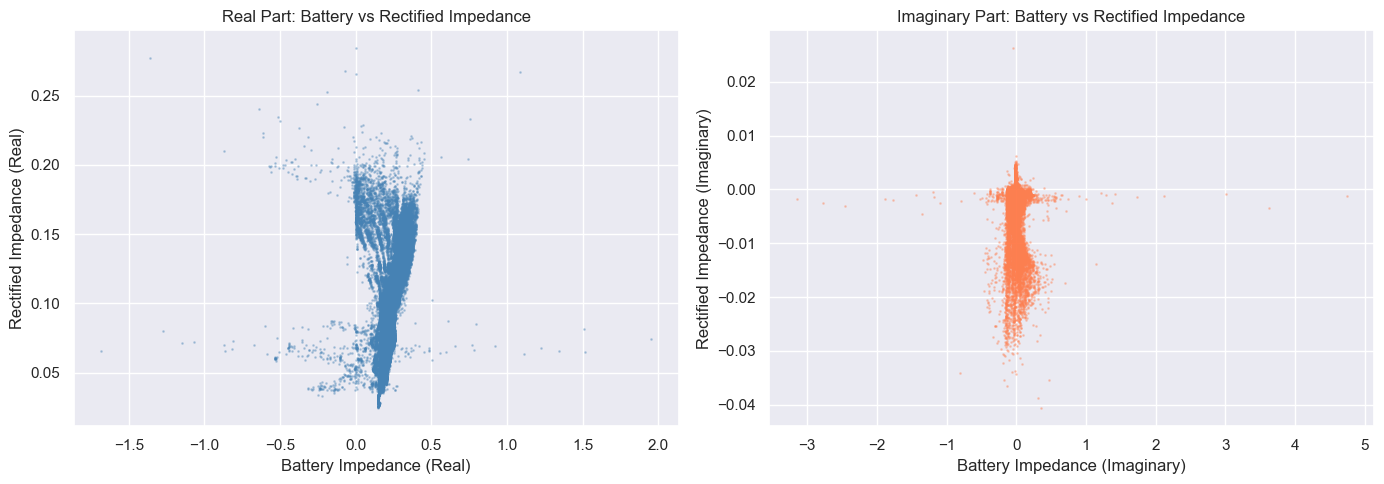

In [21]:
# ============================================================
# CELL — Now plot Battery_impedance vs Rectified_Impedance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real parts comparison
axes[0].scatter(impedance_df['Battery_impedance_real'],
                impedance_df['Rectified_Impedance_real'],
                alpha=0.3, s=1, color='steelblue')
axes[0].set_xlabel('Battery Impedance (Real)')
axes[0].set_ylabel('Rectified Impedance (Real)')
axes[0].set_title('Real Part: Battery vs Rectified Impedance')

# Imaginary parts comparison
axes[1].scatter(impedance_df['Battery_impedance_imag'],
                impedance_df['Rectified_Impedance_imag'],
                alpha=0.3, s=1, color='coral')
axes[1].set_xlabel('Battery Impedance (Imaginary)')
axes[1].set_ylabel('Rectified Impedance (Imaginary)')
axes[1].set_title('Imaginary Part: Battery vs Rectified Impedance')

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL — Fill missing Rectified_Impedance with median
# ============================================================

# Since Rectified_Impedance is tightly clustered, median is safe
median_real = impedance_df['Rectified_Impedance_real'].median()
median_imag = impedance_df['Rectified_Impedance_imag'].median()

print(f"Median real part:  {median_real:.6f}")
print(f"Median imag part:  {median_imag:.6f}")

impedance_df['Rectified_Impedance_real'] = impedance_df['Rectified_Impedance_real'].fillna(median_real)
impedance_df['Rectified_Impedance_imag'] = impedance_df['Rectified_Impedance_imag'].fillna(median_imag)

print(f"\nMissing after fill: {impedance_df['Rectified_Impedance_real'].isnull().sum()}")

Median real part:  0.086359
Median imag part:  -0.001695

Missing after fill: 0


In [23]:
# ============================================================
# CELL — Final confirmation of all dataframes
# ============================================================

print("=== FINAL SHAPES ===")
print(f"metadata (df):  {df.shape}")
print(f"charge_df:      {charge_df.shape}")
print(f"discharge_df:   {discharge_df.shape}")
print(f"impedance_df:   {impedance_df.shape}")

print("\n=== MISSING VALUES CONFIRMED ===")
for name, dataframe in [('df', df), ('charge_df', charge_df),
                         ('discharge_df', discharge_df), ('impedance_df', impedance_df)]:
    print(f"{name}: {dataframe.isnull().sum().sum()} missing values")

print("\n=== DUPLICATES CONFIRMED ===")
for name, dataframe in [('df', df), ('charge_df', charge_df),
                         ('discharge_df', discharge_df), ('impedance_df', impedance_df)]:
    print(f"{name}: {dataframe.duplicated().sum()} duplicates")

=== FINAL SHAPES ===
metadata (df):  (7531, 10)
charge_df:      (6512619, 11)
discharge_df:   (764674, 11)
impedance_df:   (75376, 14)

=== MISSING VALUES CONFIRMED ===
df: 15930 missing values
charge_df: 0 missing values
discharge_df: 0 missing values
impedance_df: 0 missing values

=== DUPLICATES CONFIRMED ===
df: 0 duplicates
charge_df: 0 duplicates
discharge_df: 0 duplicates
impedance_df: 0 duplicates


In [25]:
# ============================================================
# CELL — Save all cleaned data + documentation
# ============================================================

import os

# Create output folder
os.makedirs('data/cleaned_data', exist_ok=True)
os.makedirs('data/cleaned_data/charge_chunks', exist_ok=True)

# ── 1. Metadata ──────────────────────────────────────────────
df.to_csv('data/cleaned_data/metadata_cleaned.csv', index=False)
print("✅ metadata_cleaned.csv saved")

# ── 2. Discharge ─────────────────────────────────────────────
discharge_df.to_csv('data/cleaned_data/discharge_cleaned.csv', index=False)
print("✅ discharge_cleaned.csv saved")

# ── 3. Impedance ─────────────────────────────────────────────
impedance_df.to_csv('data/cleaned_data/impedance_cleaned.csv', index=False)
print("✅ impedance_cleaned.csv saved")

# ── 4. Charge (chunked) ──────────────────────────────────────
chunk_size  = 1_600_000
num_chunks  = len(charge_df) // chunk_size + 1

for i in range(num_chunks):
    start    = i * chunk_size
    end      = start + chunk_size
    chunk    = charge_df.iloc[start:end]
    filename = f'data/cleaned_data/charge_chunks/charge_part_{i+1:02d}_of_{num_chunks:02d}.csv'
    chunk.to_csv(filename, index=False)
    print(f"✅ charge_part_{i+1:02d}_of_{num_chunks:02d}.csv → {len(chunk):,} rows")


✅ metadata_cleaned.csv saved
✅ discharge_cleaned.csv saved
✅ impedance_cleaned.csv saved
✅ charge_part_01_of_05.csv → 1,600,000 rows
✅ charge_part_02_of_05.csv → 1,600,000 rows
✅ charge_part_03_of_05.csv → 1,600,000 rows
✅ charge_part_04_of_05.csv → 1,600,000 rows
✅ charge_part_05_of_05.csv → 112,619 rows
